# Phase 11 – Multiclass Classification Outputs

This notebook visualizes multiclass classification outputs generated by the C++ ML Core practical workflow.

It reads exported CSV files only. It does **not** train models or reimplement model logic in Python.

Input files:

```txt
outputs/practical-exercises/multiclass-classification/metrics.csv
outputs/practical-exercises/multiclass-classification/predictions.csv
outputs/practical-exercises/multiclass-classification/probabilities.csv
outputs/practical-exercises/multiclass-classification/loss_history.csv
```

Dataset:

```txt
UCI Wine
```

Target:

```txt
class
```


## 1. Load exported outputs

The notebook is expected to be run from:

```txt
notebooks/practical-workflows/
```

so paths are resolved relative to the notebook location.


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

OUTPUT_DIR = Path("../../outputs/practical-exercises/multiclass-classification")

metrics_path = OUTPUT_DIR / "metrics.csv"
predictions_path = OUTPUT_DIR / "predictions.csv"
probabilities_path = OUTPUT_DIR / "probabilities.csv"
loss_history_path = OUTPUT_DIR / "loss_history.csv"

required_paths = [
    metrics_path,
    predictions_path,
    probabilities_path,
    loss_history_path,
]

for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(f"Missing required output file: {path}")

metrics = pd.read_csv(metrics_path)
predictions = pd.read_csv(predictions_path)
probabilities = pd.read_csv(probabilities_path)
loss_history = pd.read_csv(loss_history_path)

print("metrics:", metrics.shape)
print("predictions:", predictions.shape)
print("probabilities:", probabilities.shape)
print("loss_history:", loss_history.shape)


metrics: (20, 7)
predictions: (180, 9)
probabilities: (108, 10)
loss_history: (300, 7)


## 2. Metrics table

The metrics file contains one row per model and metric.

For multiclass classification, the main metrics are:

```txt
accuracy
macro_precision
macro_recall
macro_f1
```

Macro-averaged metrics are useful because they treat each class equally and help detect whether performance is balanced across classes.


In [2]:
metrics_pivot = (
    metrics
    .pivot_table(
        index="model",
        columns="metric",
        values="value",
        aggfunc="first",
    )
    .reset_index()
)

metrics_pivot


metric,model,accuracy,macro_f1,macro_precision,macro_recall
0,DecisionTreeClassifier,0.888889,0.877778,0.906061,0.871429
1,GaussianNaiveBayes,0.972222,0.972262,0.984127,0.962963
2,KNNClassifier,0.972222,0.973909,0.966667,0.983333
3,RandomForestClassifier,1.000000,1.000000,1.000000,1.000000
4,SoftmaxRegression,0.944444,0.942690,0.925000,0.966667


## 3. Metric comparison plots

Higher is better for all displayed multiclass classification metrics:

```txt
accuracy
macro_precision
macro_recall
macro_f1
```


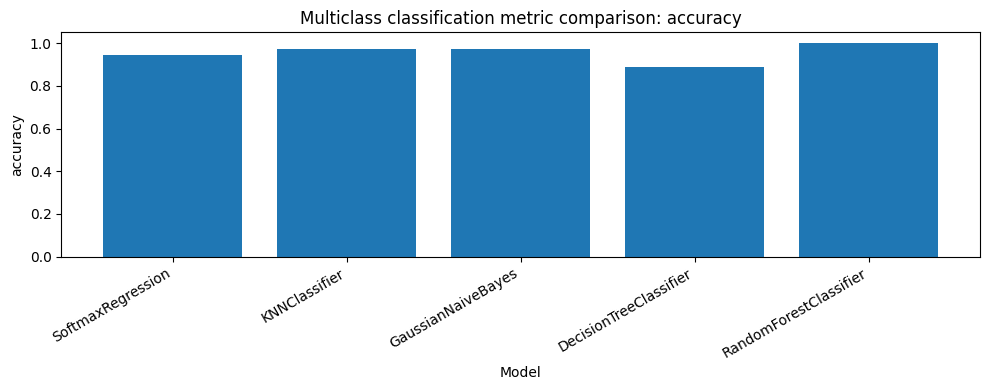

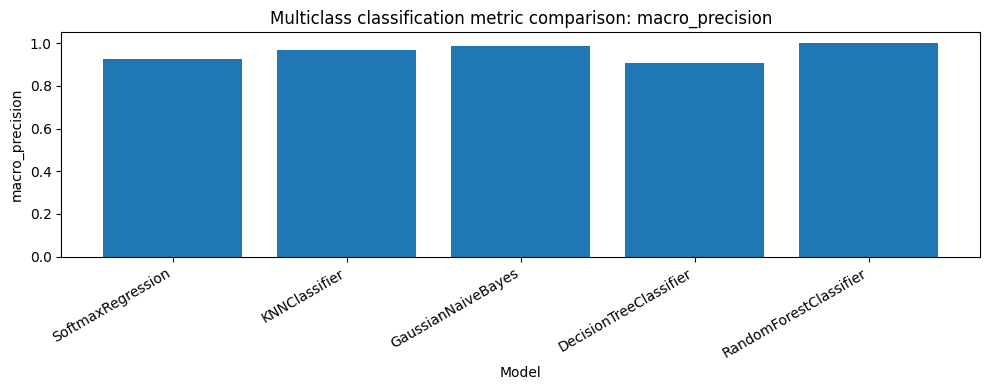

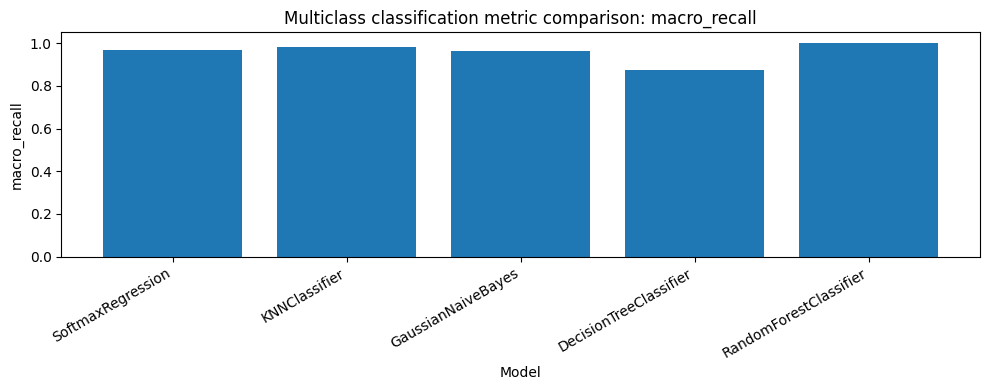

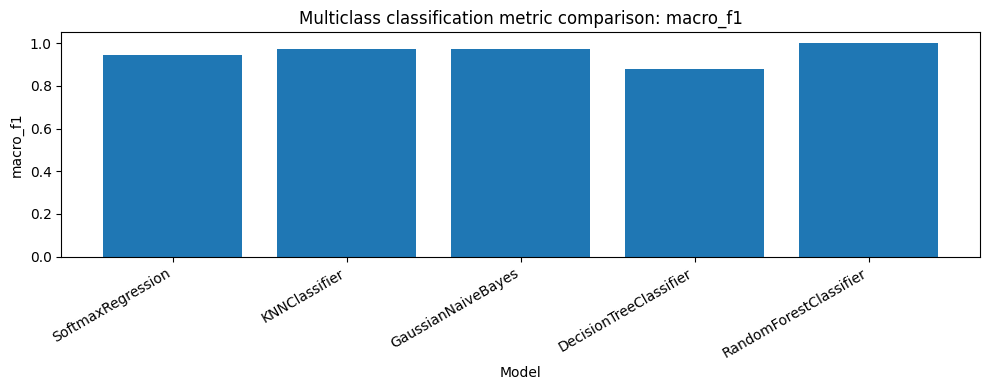

In [3]:
for metric_name in ["accuracy", "macro_precision", "macro_recall", "macro_f1"]:
    subset = metrics[metrics["metric"] == metric_name].copy()

    plt.figure(figsize=(10, 4))
    plt.bar(subset["model"], subset["value"])
    plt.title(f"Multiclass classification metric comparison: {metric_name}")
    plt.xlabel("Model")
    plt.ylabel(metric_name)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


## 4. Prediction correctness by model

The predictions file contains:

```txt
y_true
y_pred
correct
```

This section compares how many test samples each model predicted correctly.


In [4]:
correctness_summary = (
    predictions
    .groupby(["model", "correct"])
    .size()
    .reset_index(name="count")
)

correctness_summary


,model,correct,count
0,DecisionTreeClassifier,0,4
1,DecisionTreeClassifier,1,32
2,GaussianNaiveBayes,0,1
3,GaussianNaiveBayes,1,35
4,KNNClassifier,0,1
5,KNNClassifier,1,35
6,RandomForestClassifier,1,36
7,SoftmaxRegression,0,2
8,SoftmaxRegression,1,34


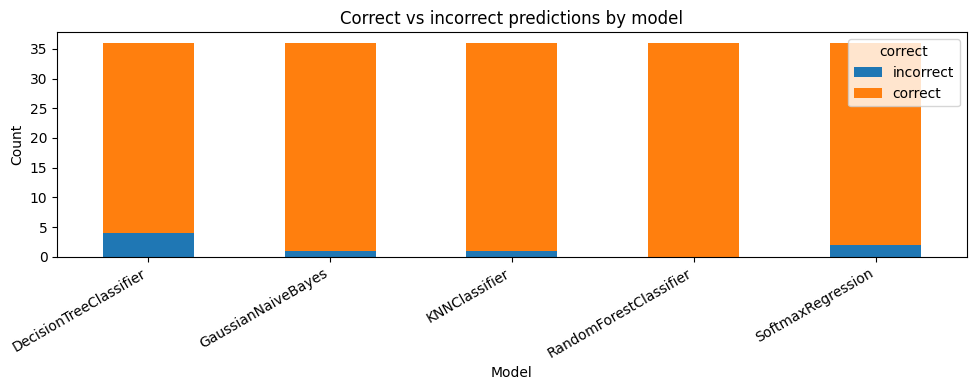

In [5]:
correctness_pivot = (
    correctness_summary
    .pivot_table(
        index="model",
        columns="correct",
        values="count",
        fill_value=0,
    )
)

correctness_pivot = correctness_pivot.rename(columns={0: "incorrect", 1: "correct"})

correctness_pivot.plot(kind="bar", stacked=True, figsize=(10, 4))
plt.title("Correct vs incorrect predictions by model")
plt.xlabel("Model")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 5. Confusion-matrix-style visualization

The workflow does not export a separate confusion matrix file.

However, the notebook can build confusion-matrix-style tables from the exported predictions:

```txt
y_true
y_pred
```

This is analysis of exported C++ outputs, not model logic reimplementation.


In [6]:
def confusion_matrix_from_predictions(dataframe: pd.DataFrame) -> pd.DataFrame:
    matrix = pd.crosstab(
        dataframe["y_true"].astype(int),
        dataframe["y_pred"].astype(int),
        rownames=["true_class"],
        colnames=["predicted_class"],
        dropna=False,
    )

    observed_classes = sorted(
        set(dataframe["y_true"].astype(int).unique())
        | set(dataframe["y_pred"].astype(int).unique())
    )

    matrix = matrix.reindex(index=observed_classes, columns=observed_classes, fill_value=0)

    return matrix


for model_name, subset in predictions.groupby("model"):
    display_matrix = confusion_matrix_from_predictions(subset)
    print(f"\nConfusion matrix – {model_name}")
    display(display_matrix)



Confusion matrix – DecisionTreeClassifier


predicted_class,0,1,2
true_class,,,
0,9,0,0
1,2,18,0
2,0,2,5



Confusion matrix – GaussianNaiveBayes


predicted_class,0,1,2
true_class,,,
0,8,1,0
1,0,20,0
2,0,0,7



Confusion matrix – KNNClassifier


predicted_class,0,1,2
true_class,,,
0,9,0,0
1,1,19,0
2,0,0,7



Confusion matrix – RandomForestClassifier


predicted_class,0,1,2
true_class,,,
0,9,0,0
1,0,20,0
2,0,0,7



Confusion matrix – SoftmaxRegression


predicted_class,0,1,2
true_class,,,
0,9,0,0
1,1,18,1
2,0,0,7


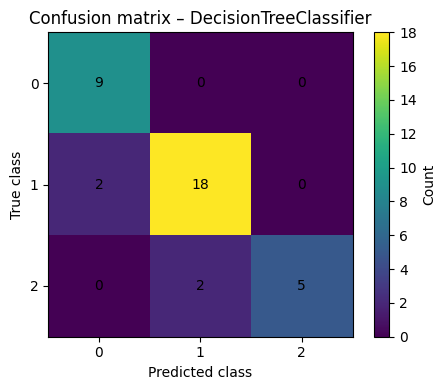

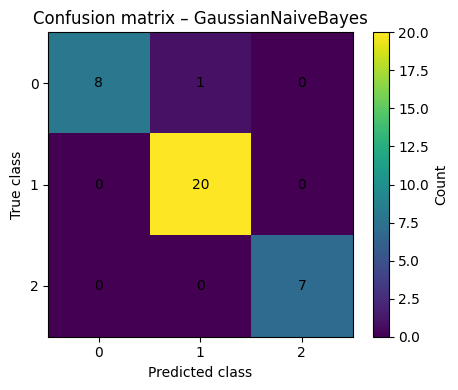

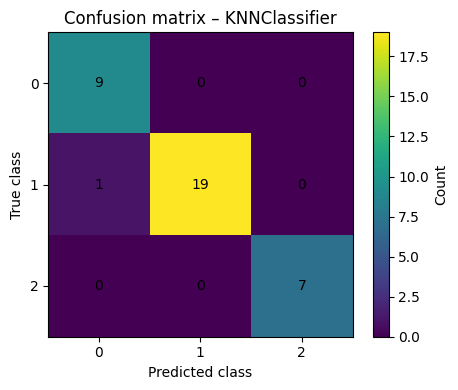

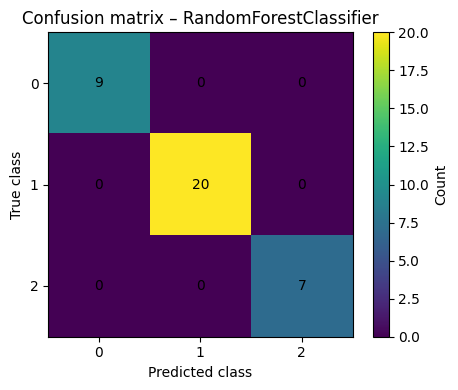

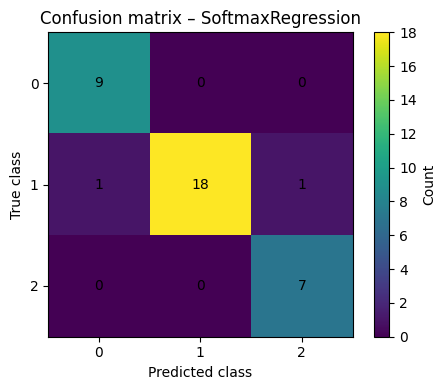

In [7]:
for model_name, subset in predictions.groupby("model"):
    matrix = confusion_matrix_from_predictions(subset)

    plt.figure(figsize=(5, 4))
    plt.imshow(matrix.values)
    plt.title(f"Confusion matrix – {model_name}")
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.xticks(range(len(matrix.columns)), matrix.columns)
    plt.yticks(range(len(matrix.index)), matrix.index)

    for row_idx in range(matrix.shape[0]):
        for col_idx in range(matrix.shape[1]):
            plt.text(
                col_idx,
                row_idx,
                str(matrix.values[row_idx, col_idx]),
                ha="center",
                va="center",
            )

    plt.colorbar(label="Count")
    plt.tight_layout()
    plt.show()


## 6. Probability distributions

The probabilities file contains one probability column per class:

```txt
probability_class_0
probability_class_1
probability_class_2
```

This section visualizes the maximum predicted probability for each model. A higher maximum probability usually indicates more confident predictions.


In [8]:
probability_columns = [
    column
    for column in probabilities.columns
    if column.startswith("probability_class_")
]

probabilities["max_probability"] = probabilities[probability_columns].max(axis=1)
probabilities["predicted_class_from_probability"] = (
    probabilities[probability_columns]
    .idxmax(axis=1)
    .str.replace("probability_class_", "", regex=False)
    .astype(int)
)

probabilities.head()


,run_id,row_id,workflow,dataset,model,split,y_true,probability_class_0,probability_class_1,probability_class_2,max_probability,predicted_class_from_probability
0,softmax_regression_baseline,0,multiclass_classification,wine,SoftmaxRegression,test,1,0.119155,0.756745,0.124100,0.756745,1
1,softmax_regression_baseline,1,multiclass_classification,wine,SoftmaxRegression,test,1,0.071625,0.906059,0.022316,0.906059,1
2,softmax_regression_baseline,2,multiclass_classification,wine,SoftmaxRegression,test,0,0.935488,0.016611,0.047901,0.935488,0
3,softmax_regression_baseline,3,multiclass_classification,wine,SoftmaxRegression,test,1,0.201445,0.772290,0.026265,0.772290,1
4,softmax_regression_baseline,4,multiclass_classification,wine,SoftmaxRegression,test,1,0.025938,0.910163,0.063899,0.910163,1


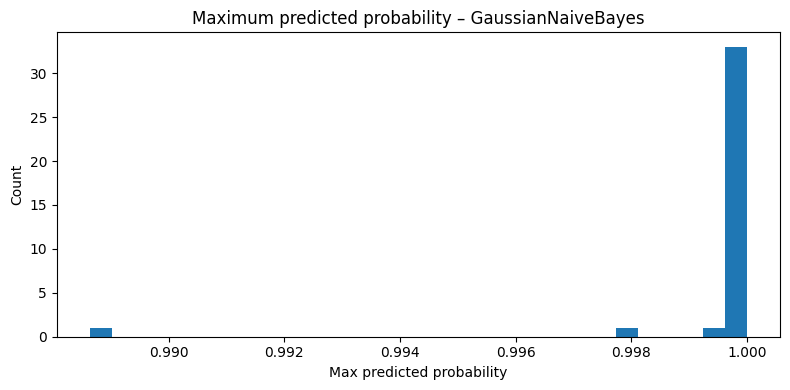

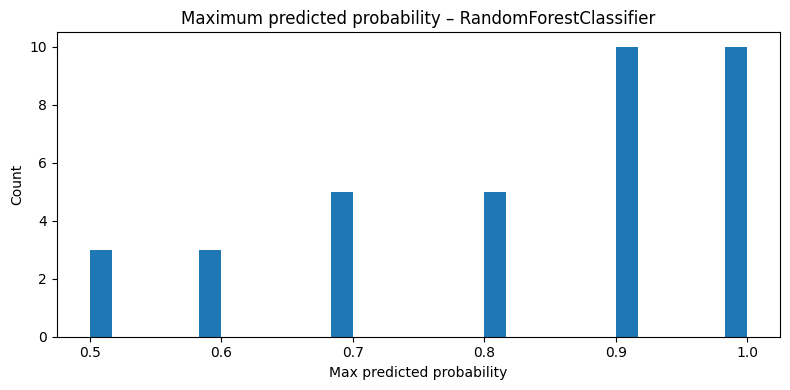

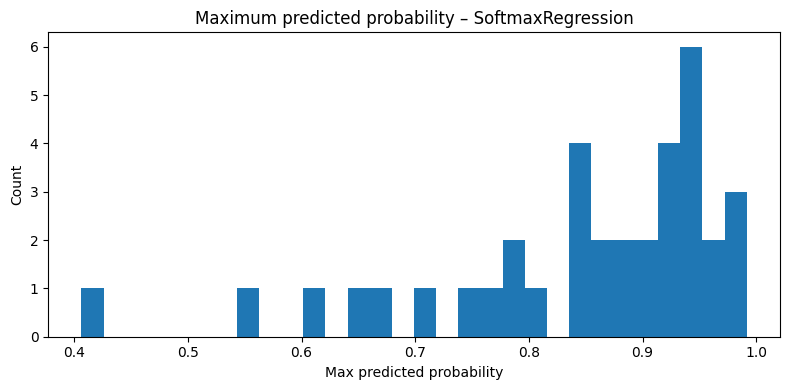

In [9]:
for model_name, subset in probabilities.groupby("model"):
    plt.figure(figsize=(8, 4))
    plt.hist(subset["max_probability"], bins=30)
    plt.title(f"Maximum predicted probability – {model_name}")
    plt.xlabel("Max predicted probability")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


## 7. Probability assigned to the true class

This plot shows how much probability each model assigns to the correct class.

Higher values are better.


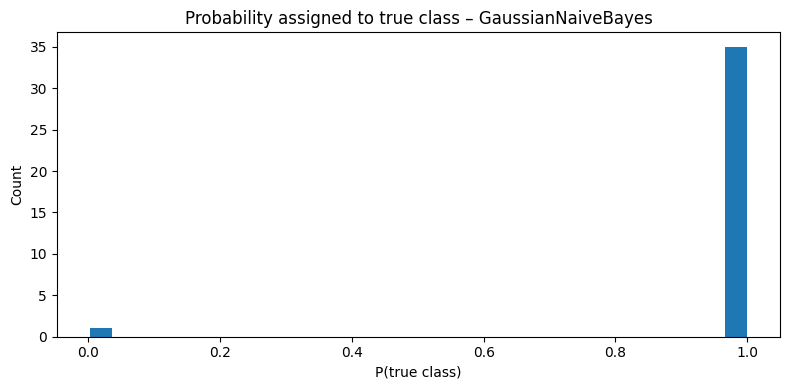

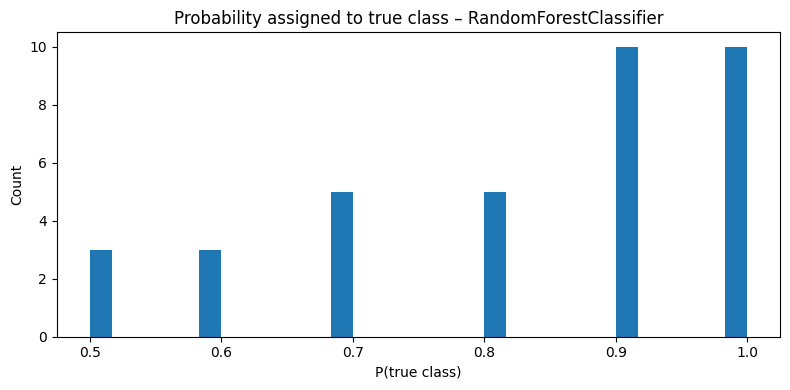

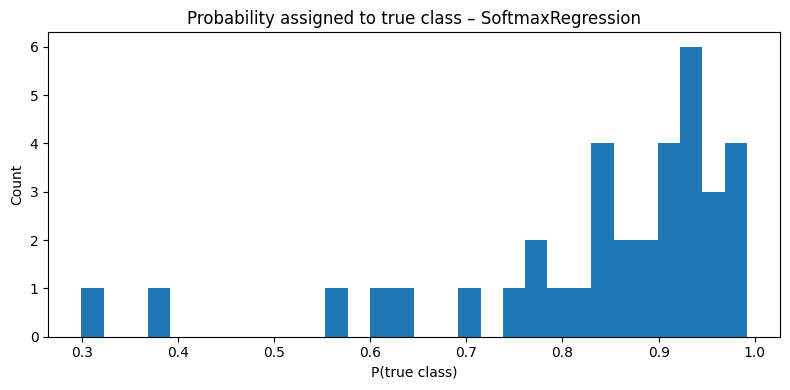

In [10]:
def probability_of_true_class(row: pd.Series) -> float:
    true_class = int(row["y_true"])
    return float(row[f"probability_class_{true_class}"])


probabilities["probability_true_class"] = probabilities.apply(probability_of_true_class, axis=1)

for model_name, subset in probabilities.groupby("model"):
    plt.figure(figsize=(8, 4))
    plt.hist(subset["probability_true_class"], bins=30)
    plt.title(f"Probability assigned to true class – {model_name}")
    plt.xlabel("P(true class)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


## 8. Loss history

Loss history is available for iterative trainable models.

In this workflow, it can include:

```txt
SoftmaxRegression
```

The loss curve helps verify whether training is stable.


In [11]:
loss_history.head()


,run_id,workflow,dataset,model,split,iteration,loss
0,softmax_regression_baseline,multiclass_classification,wine,SoftmaxRegression,train,0,1.098612
1,softmax_regression_baseline,multiclass_classification,wine,SoftmaxRegression,train,1,1.079620
2,softmax_regression_baseline,multiclass_classification,wine,SoftmaxRegression,train,2,1.061146
3,softmax_regression_baseline,multiclass_classification,wine,SoftmaxRegression,train,3,1.043176
4,softmax_regression_baseline,multiclass_classification,wine,SoftmaxRegression,train,4,1.025700


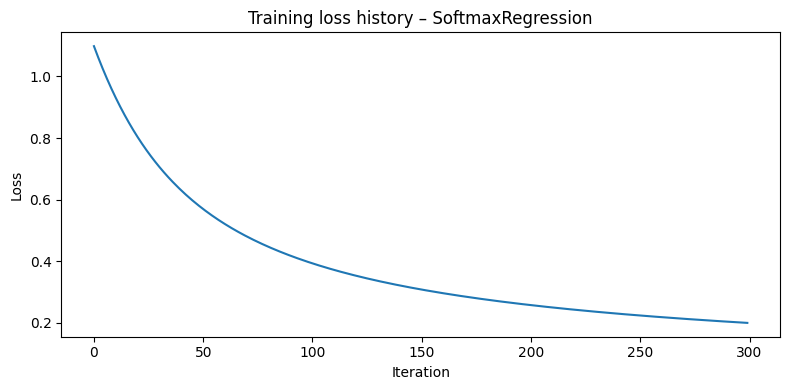

In [12]:
for model_name, subset in loss_history.groupby("model"):
    plt.figure(figsize=(8, 4))
    plt.plot(subset["iteration"], subset["loss"])
    plt.title(f"Training loss history – {model_name}")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.tight_layout()
    plt.show()


## 9. Interpretation notes

This notebook is for visualization only.

The Wine dataset is relatively well-separated after standardization, so strong multiclass metrics are expected.

Important interpretation rules:

```txt
High accuracy:
  most samples are classified correctly

High macro precision:
  predicted classes are usually reliable across classes

High macro recall:
  each true class is being recovered well

High macro F1:
  good balance between macro precision and macro recall
```

The confusion-matrix-style tables help identify which specific classes are confused by each model.
